# Waste Classification with YOLOv8

Fine-tune YOLOv8n-cls on TrashNet (`cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`).
This notebook prepares an 80/20 split, trains for 25 epochs, then classifies a test image and launches a Gradio demo.


In [1]:
!pip install ultralytics


  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached nvidia_ml_py-13.610.43-py3-none-any.whl.metadata (9.7 kB)
  Using cached ultralytics_thop-2.1.6-py3-none-any.whl.metadata (13 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.4 MB 799.2 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.4 MB 817.9 kB/s eta 0:00:01
   ----------------------------- ---------- 1.0/1.4 MB 882.6 kB/s eta 0:00:01
   ------------

In [2]:
!pip install matplotlib pillow

In [3]:
import os
import shutil
import random

source_dir = r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized"
target_dir = r"C:\Users\LENOVO\Downloads\yolo_trashnet"

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Create folder structure
for cls in classes:
    os.makedirs(os.path.join(target_dir, 'train', cls), exist_ok=True)
    os.makedirs(os.path.join(target_dir, 'val', cls), exist_ok=True)
    
    src_cls_dir = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(src_cls_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(images)
    
    split_idx = int(len(images) * 0.8)
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]
    
    for img in train_imgs:
        shutil.copy(os.path.join(src_cls_dir, img), os.path.join(target_dir, 'train', cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_cls_dir, img), os.path.join(target_dir, 'val', cls, img))

print("Dataset prepared for waste classification with YOLOv8.")


Dataset prepared for YOLOv8 classification!


In [4]:
from ultralytics import YOLO

# Load pretrained YOLOv8n-cls for waste classification
model = YOLO('yolov8n-cls.pt')

# Train waste classification with YOLOv8
results = model.train(
    data=r"C:\Users\LENOVO\Downloads\yolo_trashnet",
    epochs=25,
    imgsz=224,
    batch=32,
    project="waste_classification",
    name="waste_classification_with_yolov8"
)


WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\LENOVO\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.150  Python-3.12.7 torch-2.14.0+cpu CPU (11th Gen Intel Core i5-1145G7 @ 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\LENOVO\Downloads\yolo_trashnet, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None


image 1/1 C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\paper\paper100.jpg: 224x224 paper 1.00, cardboard 0.00, trash 0.00, metal 0.00, plastic 0.00, 33.1ms
Speed: 7.6ms preprocess, 33.1ms inference, 1.7ms postprocess per image at shape (1, 3, 224, 224)


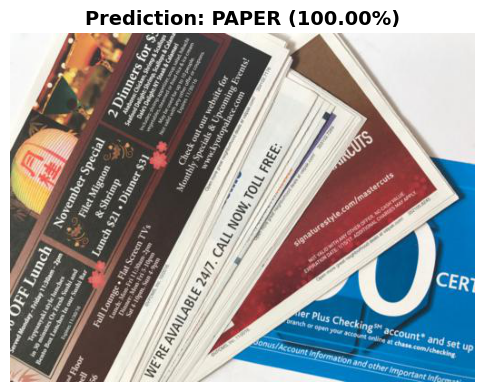

In [7]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

# Load trained waste-classification-with-yolov8 weights
trained_model = YOLO(r"C:\runs\classify\waste_classification\yolov8_trashnet\weights\best.pt")

# Run prediction
test_img_path = r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\paper\paper100.jpg"
results = trained_model(test_img_path)

# Extract prediction details
top1_idx = results[0].probs.top1
top1_class = results[0].names[top1_idx]
confidence = float(results[0].probs.top1conf)

# Plot image with output
img = Image.open(test_img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction: {top1_class.upper()} ({confidence*100:.2f}%)", fontdict={'size': 14, 'weight': 'bold'})
plt.axis('off')
plt.show()


In [ ]:
import gradio as gr
import numpy as np
from ultralytics import YOLO

# Load best waste-classification-with-yolov8 weights
model = YOLO(r"C:\runs\classify\waste_classification\yolov8_trashnet\weights\best.pt")

def classify_image(img):
    if img is None:
        return "No image uploaded."
    
    # Run prediction directly on NumPy array from Gradio
    results = model(img)
    probs = results[0].probs
    names = results[0].names
    
    # Return dictionary of class probabilities for Gradio Label
    return {names[i]: float(probs.data[i]) for i in range(len(names))}

interface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=gr.Label(num_top_classes=3, label="Top Predictions"),
    title="♻️ Waste Classification with YOLOv8"
)

# Inline execution inside Jupyter Notebook
interface.launch(inline=True)


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.



0: 224x224 paper 0.71, cardboard 0.26, plastic 0.02, trash 0.00, glass 0.00, 43.6ms
Speed: 6.3ms preprocess, 43.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

0: 224x224 paper 0.71, cardboard 0.26, plastic 0.02, trash 0.00, glass 0.00, 248.4ms
Speed: 27.6ms preprocess, 248.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

0: 224x224 trash 1.00, paper 0.00, plastic 0.00, cardboard 0.00, metal 0.00, 172.0ms
Speed: 15.2ms preprocess, 172.0ms inference, 0.5ms postprocess per image at shape (1, 3, 224, 224)
Created dataset file at: .gradio\flagged\dataset1.csv

0: 224x224 plastic 0.62, trash 0.33, metal 0.05, paper 0.00, cardboard 0.00, 66.4ms
Speed: 14.9ms preprocess, 66.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

0: 224x224 plastic 0.42, trash 0.23, glass 0.19, cardboard 0.08, metal 0.06, 38.3ms
Speed: 14.9ms preprocess, 38.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


In [8]:
!pip install gradio